In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import requests
import json
from datetime import date
from dotenv import load_dotenv
import os
import sys
from tqdm import tqdm

In [4]:
load_dotenv()

True

In [42]:
df = pd.read_csv("ISO-NE Fern load profile(Sheet1).csv", parse_dates=True, index_col='Date')
df.head()

,MWh
Date,
2026-01-23,366414
2026-01-24,401868
2026-01-25,430567
2026-01-26,408045
2026-01-27,419627


In [31]:
BASE_URL = "https://webservices.iso-ne.com/api/v1.1"
market = "realtimehourlydemand"
fmt = ".json"
dates = pd.date_range('2026-01-23','2026-02-11', freq='D')
# d = date(2026, 1, 23)
location_ids = list(range(4001,4009))

auth = (os.environ["ISONE_USERNAME"], os.environ["ISONE_PASSWORD"])
full_frames = []
for d in tqdm(dates):
    frames = []
    for loc in location_ids:
        url = "/".join([BASE_URL, 
                        market, 
                        'day', 
                        d.strftime("%Y%m%d"), 
                        'location', 
                        str(loc)]) + fmt
        r = requests.get(url, auth=auth, headers={"Accept":"application/json"})
        if r.status_code != 200:
            print(f"Status Code: {r.status_code} for url: {url}")
        data = r.json()['HourlyRtDemands']['HourlyRtDemand']
        df = pd.DataFrame(data)
        df['BeginDate'] = pd.to_datetime(df['BeginDate'], utc=False)
        df = df[['BeginDate', 'Load']]
        df.columns = ['datetime',loc]
        df.set_index('datetime', inplace=True)
        frames.append(df)
    full_frames.append(pd.concat(frames, axis=1))

  0%|          | 0/20 [00:00<?, ?it/s]

100%|██████████| 20/20 [00:29<00:00,  1.47s/it]


In [ ]:
full_df = pd.concat(full_frames).resample("D").sum()

C:\Users\SDotson\AppData\Local\Temp\ipykernel_41812\55927698.py:1: Pandas4Warning: 'd' is deprecated and will be removed in a future version, please use 'D' instead.
  full_df = pd.concat(full_frames).resample("d").sum()


In [47]:

df.index = df.index.tz_localize('US/Eastern')

,MWh
datetime,
2026-01-23 00:00:00-05:00,366414.0
2026-01-24 00:00:00-05:00,401868.0
2026-01-25 00:00:00-05:00,430567.0
2026-01-26 00:00:00-05:00,408045.0
2026-01-27 00:00:00-05:00,419627.0
2026-01-28 00:00:00-05:00,419281.0
2026-01-29 00:00:00-05:00,419208.0
2026-01-30 00:00:00-05:00,430854.0
2026-01-31 00:00:00-05:00,413363.0


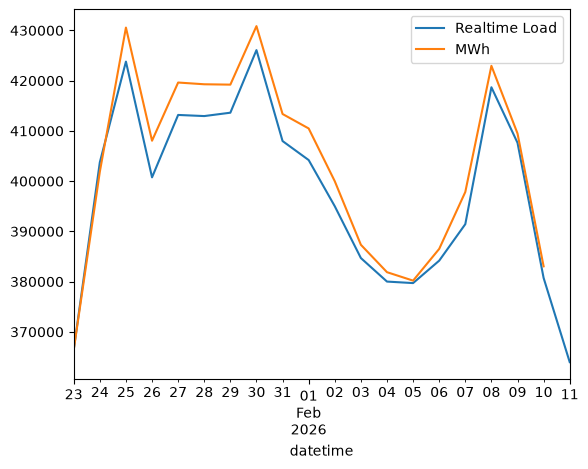

In [51]:
fig, ax = plt.subplots()
full_df.sum(axis=1).plot(ax=ax, label='Realtime Load')
df.reindex(full_df.index).plot(ax=ax, label='Unknown')
ax.legend()